In [1]:
import pandas as pd

dataset = pd.read_csv('dataset_preprocessed.csv')

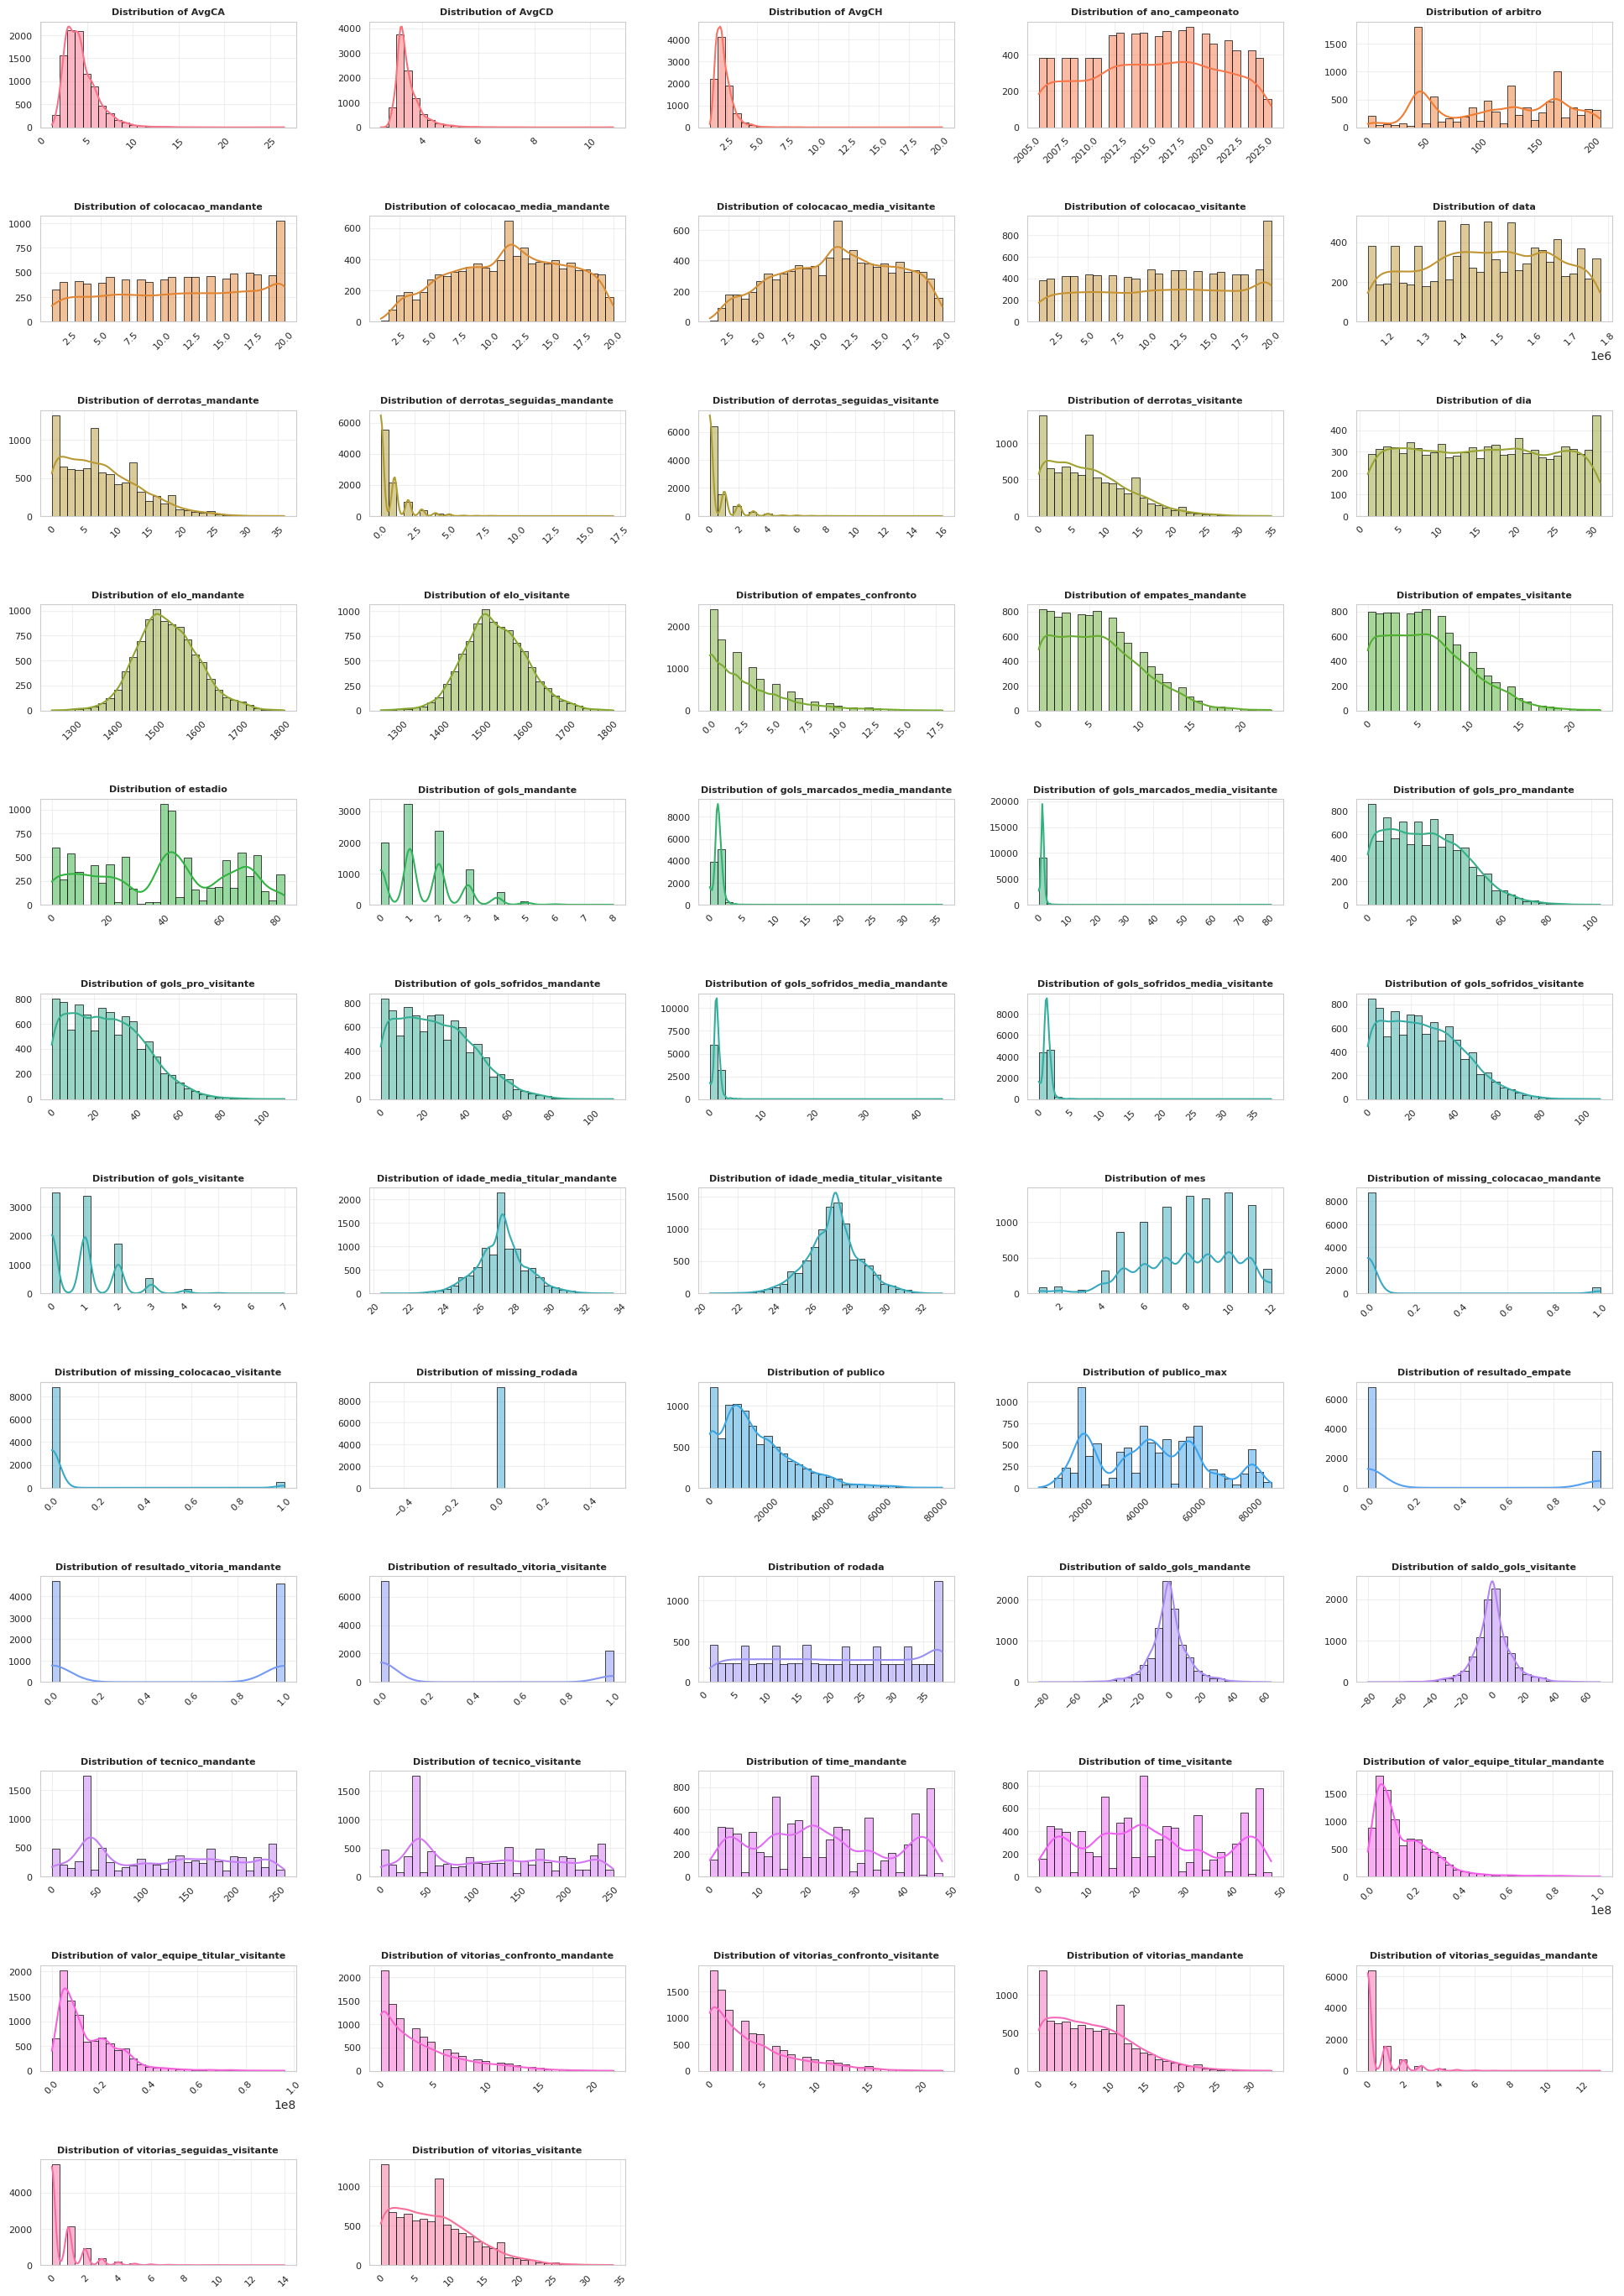

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distributions(dataset):    
    # Set a visually appealing style for the plots
    sns.set_style('whitegrid')

    # Get the list of all columns in the dataset and sort them alphabetically
    columns = sorted(dataset.columns)
    num_columns = len(columns)

    # Define the grid size
    n_rows = 12
    n_cols = 5

    # Create the subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 28))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Create a color palette
    palette = sns.color_palette("husl", num_columns)

    # Loop through the columns and plot a histogram for each
    for i, col in enumerate(columns):
        sns.histplot(dataset[col], kde=True, ax=axes[i], bins=30, color=palette[i], edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'Distribution of {col}', fontsize=8, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplots
    for i in range(num_columns, len(axes)):
        axes[i].set_visible(False)

    # Adjust the layout to prevent titles and labels from overlapping
    plt.tight_layout(pad=3.0)

    # Display the plots
    plt.savefig('distributions.png', dpi=300)

plot_distributions(dataset)

In [3]:
# To calculate the Elo ratings, we need to process home and away games separately and then combine them.
# Create a dataframe for home games
elo_mandante_df = dataset[['ano_campeonato', 'time_mandante', 'elo_mandante']].copy()
elo_mandante_df.rename(columns={'time_mandante': 'time', 'elo_mandante': 'elo'}, inplace=True)

# Create a dataframe for away games
elo_visitante_df = dataset[['ano_campeonato', 'time_visitante', 'elo_visitante']].copy()
elo_visitante_df.rename(columns={'time_visitante': 'time', 'elo_visitante': 'elo'}, inplace=True)

# Concatenate the home and away dataframes
elo_df = pd.concat([elo_mandante_df, elo_visitante_df], ignore_index=True)

# Calculate the average Elo for each team per year
elo_por_ano = elo_df.groupby(['ano_campeonato', 'time'])['elo'].mean().unstack()

# Calculate the overall average Elo for each team across all seasons
elo_geral = elo_df.groupby('time')['elo'].mean().sort_values(ascending=False)

print("Média de Elo por time em todas as temporadas:")
print(elo_geral)

Média de Elo por time em todas as temporadas:
time
21    1594.583360
33    1587.996837
45    1584.343005
26    1577.468875
4     1570.607430
47    1569.979378
28    1567.622420
13    1567.454628
16    1562.986411
42    1559.721731
2     1552.444901
41    1546.013193
22    1544.255326
38    1539.803502
8     1535.493370
23    1520.228631
5     1515.083352
46    1506.829955
18    1498.940469
7     1497.445306
25    1496.402028
11    1495.853624
17    1495.827873
24    1491.472898
27    1488.373234
19    1485.066164
43    1482.509124
14    1481.618642
20    1479.912259
44    1477.611559
37    1477.485674
36    1476.231350
40    1475.235711
15    1472.666440
3     1470.939596
48    1470.104945
12    1467.142778
34    1460.394947
32    1456.616823
0     1450.417878
29    1446.519536
10    1444.617437
30    1443.792439
6     1443.589665
31    1442.276772
39    1421.184301
1     1377.099557
Name: elo, dtype: float64


In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

dist_normais_labels = ['saldo_gols_mandante', 'saldo_gols_visitante', 'idade_media_titular_mandante',
                       'idade_media_titular_visitante', 'colocacao_media_mandante', 'colocacao_media_visitante', 'elo_mandante', 'elo_visitante']

dist_cauda_longa_labels = ['publico', 'publico_max', 'valor_equipe_titular_mandante',
                           'valor_equipe_titular_visitante']

dist_poisson_labels = ['vitorias_mandante', 'vitorias_visitante', 'empates_mandante', 
                       'empates_visitante', 'derrotas_mandante', 'derrotas_visitante', 
                       'gols_pro_mandante', 'gols_pro_visitante', 'gols_sofridos_mandante',
                       'gols_sofridos_visitante', 'empates_confronto', 'vitorias_confronto_mandante', 
                       'vitorias_confronto_visitante',
                       'gols_marcados_media_mandante', 'gols_marcados_media_visitante',
                        'gols_sofridos_media_mandante', 'gols_sofridos_media_visitante',
                        'vitorias_seguidas_mandante', 'vitorias_seguidas_visitante',
                        'derrotas_seguidas_mandante', 'derrotas_seguidas_visitante',
                        'AvgCH', 'AvgCD', 'AvgCA']

#dist_categoricas_ciclicas_labels = ['data', 'rodada', 'time_mandante', 'time_visitante',
#                                    'colocacao_mandante', 'colocacao_visitante', 'dia', 'mes',
#                                    'estadio', 'arbitro', 'tecnico_mandante', 'tecnico_visitante']

dist_categoricas_ciclicas_labels = ['data', 'rodada', 'colocacao_mandante', 'colocacao_visitante', 'dia', 'mes']

# Initialize scalers
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

# Apply StandardScaler to normally distributed columns
for col in dist_normais_labels:
    if col in dataset.columns:
        dataset[col] = standard_scaler.fit_transform(dataset[[col]])

# Apply log transformation and then MinMaxScaler to long-tail distributed columns
for col in dist_cauda_longa_labels:
    if col in dataset.columns:
        dataset[col] = np.log1p(dataset[col])
        dataset[col] = min_max_scaler.fit_transform(dataset[[col]])

# Combine Poisson and cyclical categorical labels
dist_minmax_labels = dist_poisson_labels + dist_categoricas_ciclicas_labels

# Apply MinMaxScaler to the combined list of columns
for col in dist_minmax_labels:
    if col in dataset.columns:
        dataset[col] = min_max_scaler.fit_transform(dataset[[col]])

print("Scaling and transformations applied successfully.")
dataset.describe()

Scaling and transformations applied successfully.


,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,vitorias_confronto_visitante,empates_confronto,vitorias_seguidas_mandante,vitorias_seguidas_visitante,colocacao_media_mandante,colocacao_media_visitante,derrotas_seguidas_mandante,derrotas_seguidas_visitante,elo_mandante,elo_visitante
count,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,9294.000000,...,9294.000000,9294.000000,9294.000000,9294.000000,9.294000e+03,9.294000e+03,9294.000000,9294.000000,9.294000e+03,9.294000e+03
mean,2015.954056,0.513374,0.539197,39.701743,113.187218,0.754200,0.726127,22.789864,22.789111,116.855283,...,0.171988,0.152458,0.043783,0.051554,1.697229e-16,-6.727756e-17,0.042665,0.036771,1.388364e-15,-1.036686e-15
std,5.576516,0.277235,0.316921,24.059266,56.321226,0.269183,0.172447,13.515890,13.500309,76.751051,...,0.177031,0.162810,0.085396,0.084555,1.000054e+00,1.000054e+00,0.070819,0.073708,1.000054e+00,1.000054e+00
min,2006.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-2.301667e+00,-2.291715e+00,0.000000,0.000000,-3.803272e+00,-3.695971e+00
25%,2012.000000,0.306290,0.270270,19.000000,57.000000,0.783368,0.557316,13.000000,13.000000,42.000000,...,0.045455,0.000000,0.000000,0.000000,-7.768067e-01,-7.687454e-01,0.000000,0.000000,-6.766327e-01,-6.737749e-01
50%,2016.000000,0.518195,0.540541,42.000000,118.000000,0.838008,0.757825,22.000000,22.000000,109.000000,...,0.136364,0.111111,0.000000,0.000000,1.285303e-02,1.087010e-02,0.000000,0.000000,-6.077483e-02,-6.425022e-02
75%,2020.000000,0.740221,0.837838,62.000000,166.000000,0.887606,0.856823,33.000000,33.000000,182.000000,...,0.272727,0.222222,0.076923,0.071429,8.011040e-01,8.117050e-01,0.058824,0.062500,6.427459e-01,6.597560e-01
max,2026.000000,1.000000,1.000000,83.000000,207.000000,1.000000,1.000000,48.000000,48.000000,258.000000,...,1.000000,1.000000,1.000000,1.000000,1.837239e+00,1.842060e+00,1.000000,1.000000,3.837841e+00,3.798756e+00


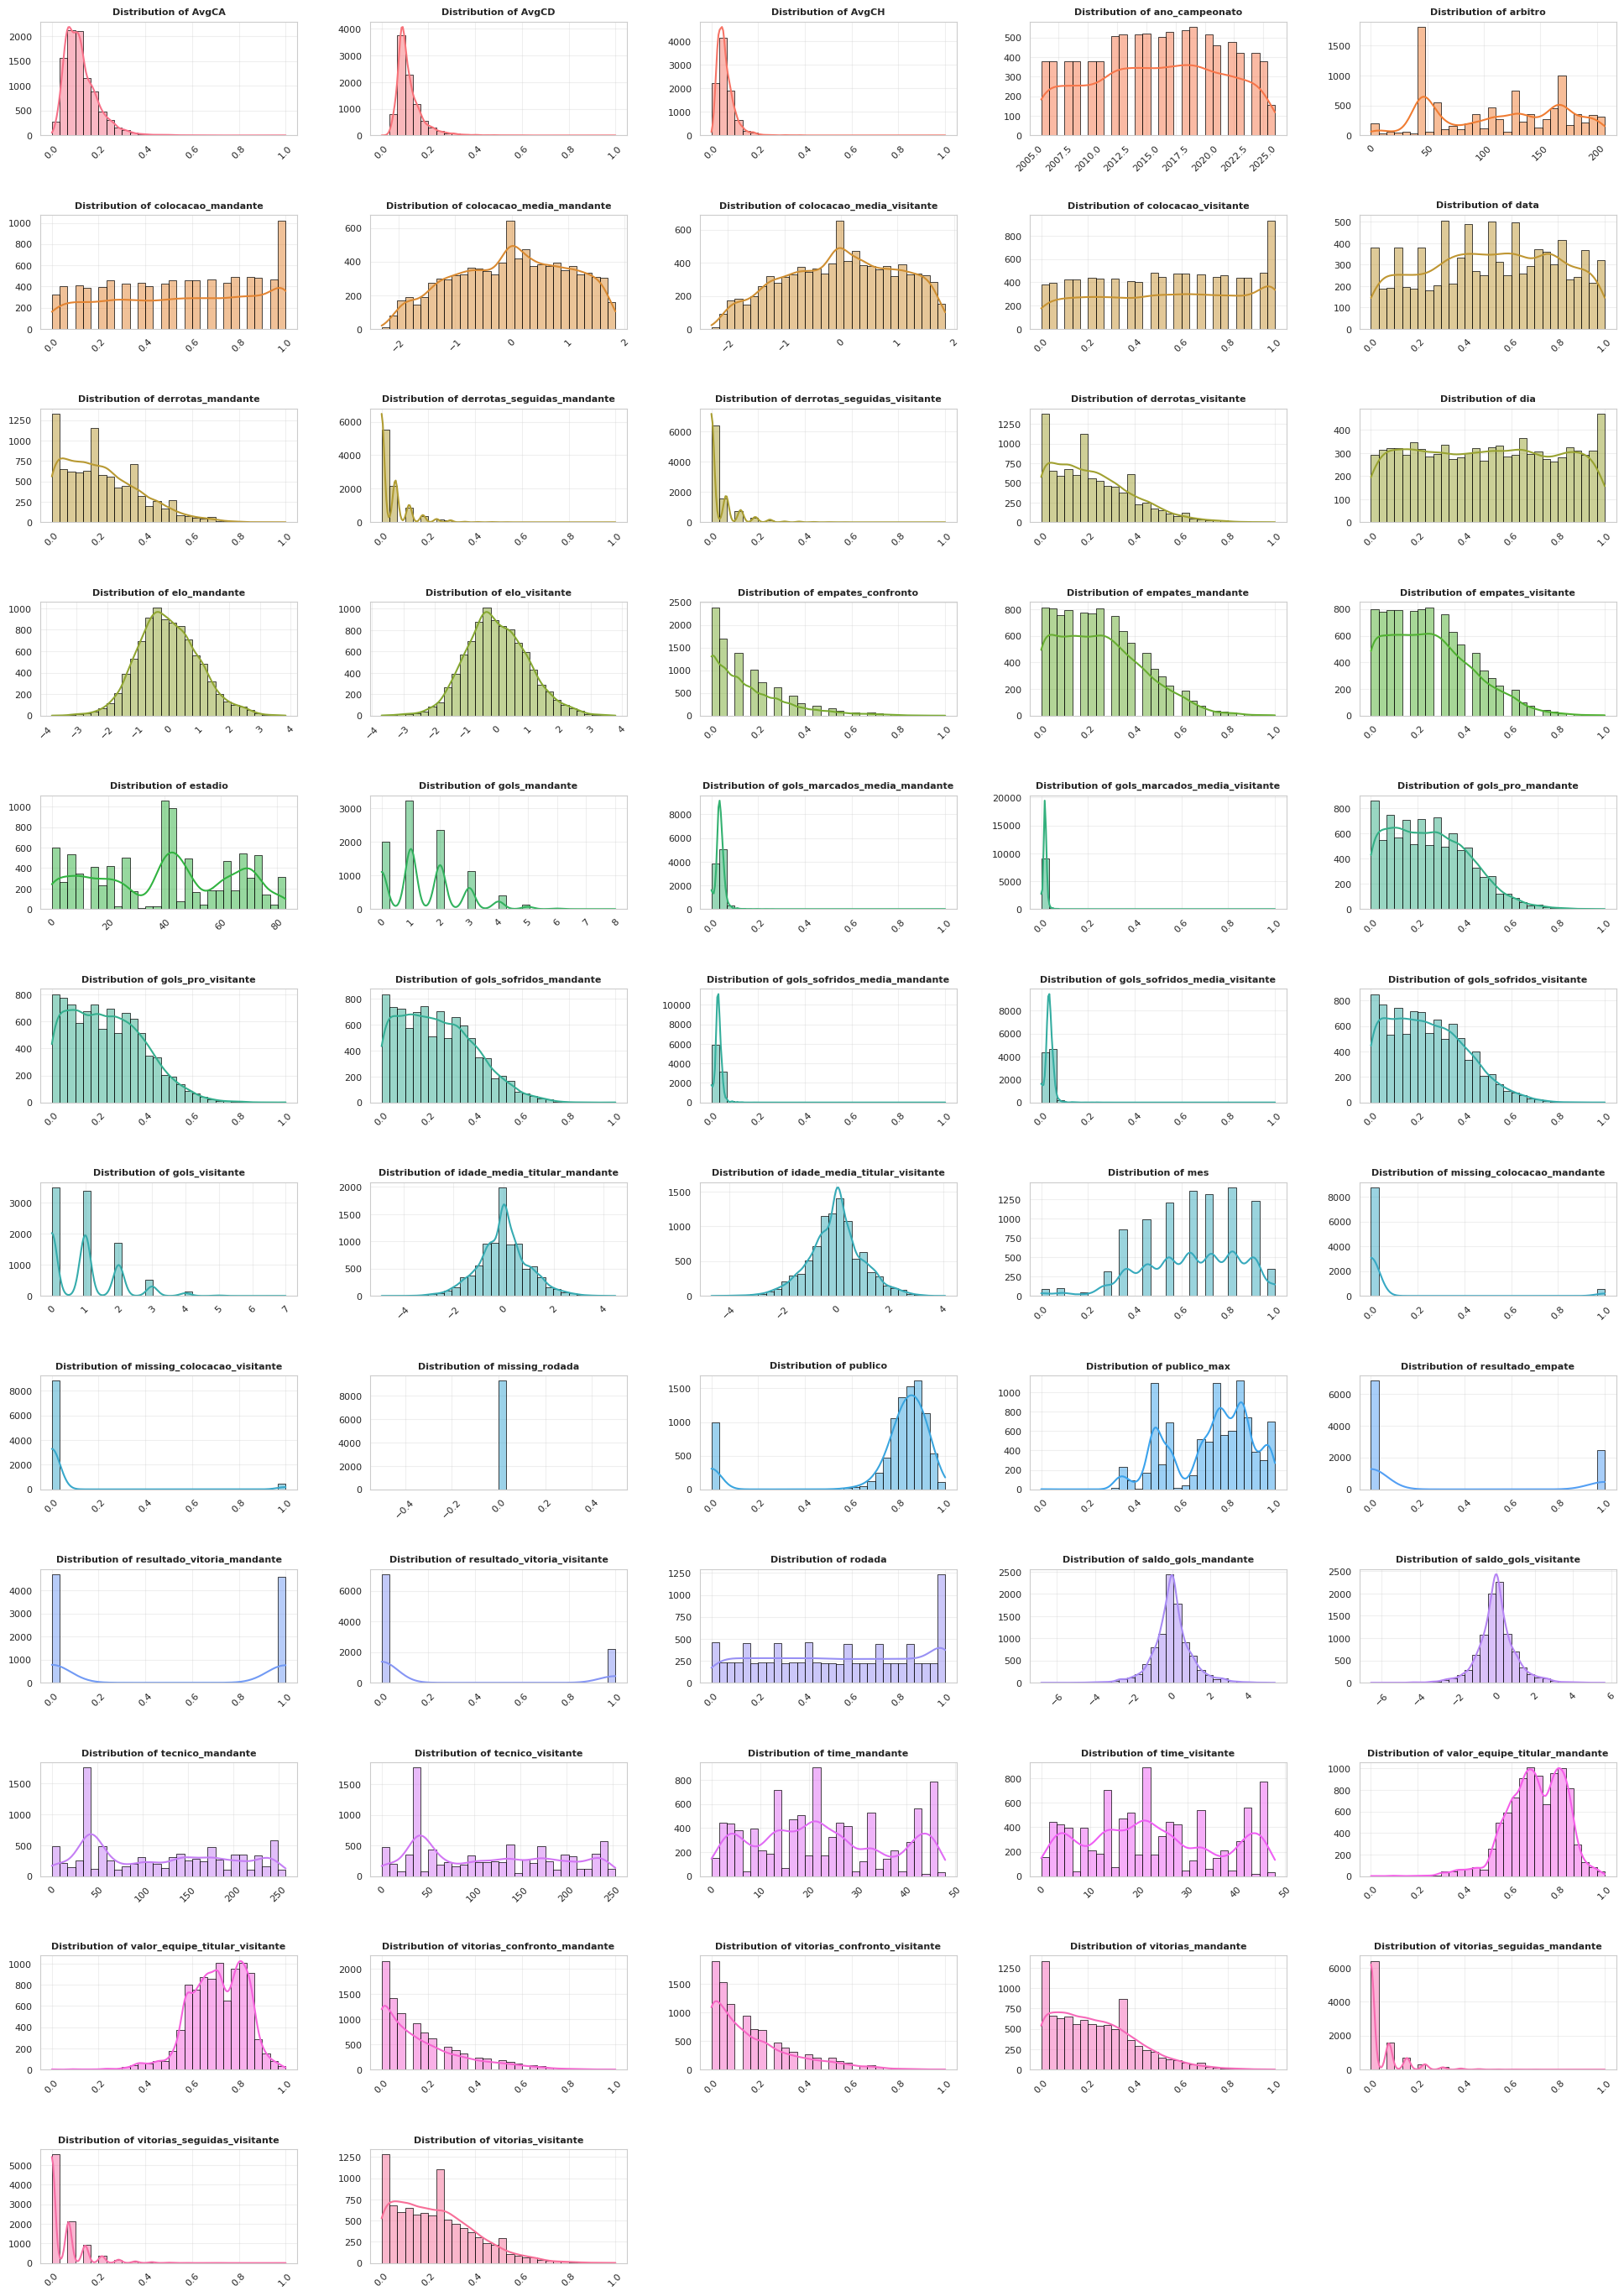

In [5]:
plot_distributions(dataset)

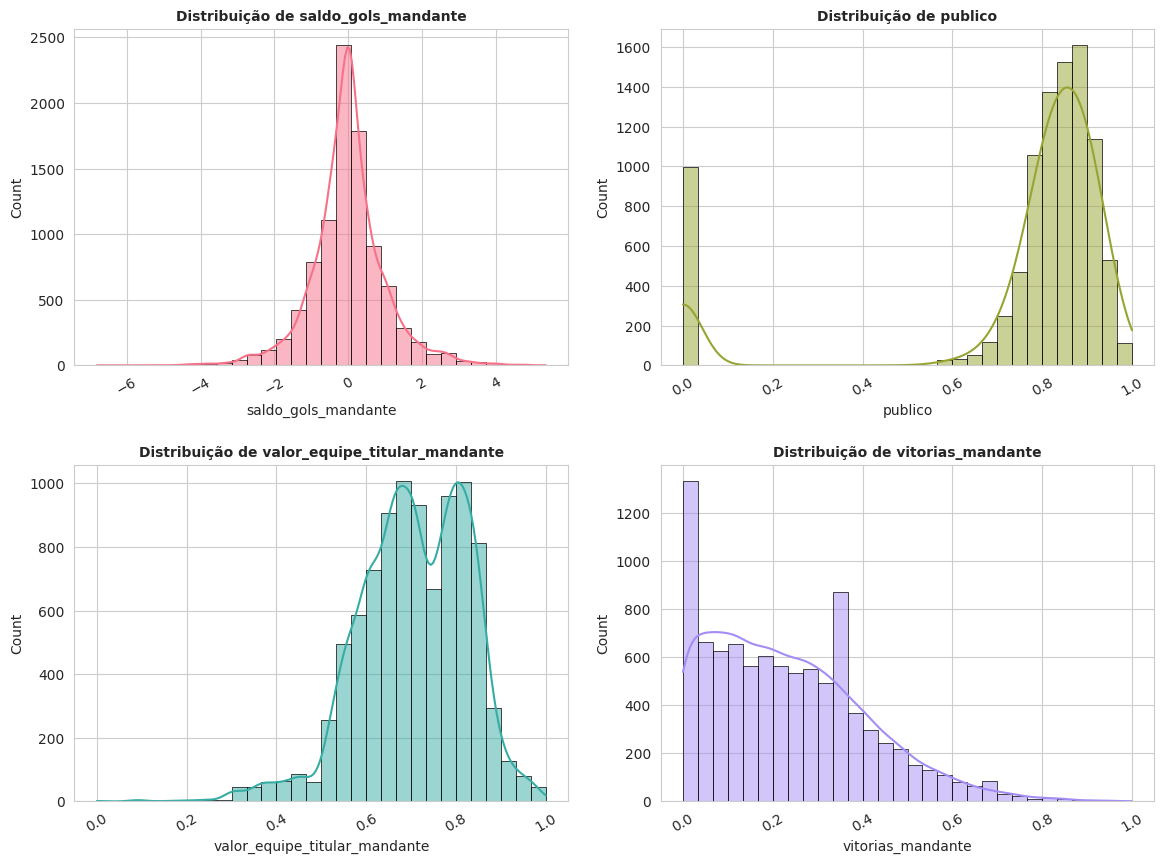

In [6]:
# Plot 4 distribuições em 2x2
cols = ['saldo_gols_mandante', 'publico', 'valor_equipe_titular_mandante', 'vitorias_mandante']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
palette = sns.color_palette('husl', len(cols))

for ax, col, color in zip(axes, cols, palette):
    if col in dataset.columns:
        sns.histplot(dataset[col].dropna(), kde=True, bins=30, ax=ax, color=color, edgecolor='black', linewidth=0.5)
        ax.set_title(f'Distribuição de {col}', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
    else:
        ax.text(0.5, 0.5, f'Coluna "{col}" não encontrada', ha='center', va='center')
        ax.set_axis_off()

plt.tight_layout(pad=2.0)
plt.savefig('four_distributions_2x2.png', dpi=300)
plt.show()

In [7]:
dataset.to_csv('dataset_scaled.csv', index=False)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9294 entries, 0 to 9293
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  9294 non-null   int64  
 1   data                            9294 non-null   float64
 2   rodada                          9294 non-null   float64
 3   estadio                         9294 non-null   int64  
 4   arbitro                         9294 non-null   int64  
 5   publico                         9294 non-null   float64
 6   publico_max                     9294 non-null   float64
 7   time_mandante                   9294 non-null   int64  
 8   time_visitante                  9294 non-null   int64  
 9   tecnico_mandante                9294 non-null   int64  
 10  tecnico_visitante               9294 non-null   int64  
 11  colocacao_mandante              9294 non-null   float64
 12  colocacao_visitante             9294 non-null